## 1. Understand the data.
<p>In this assignment, you will delve into the exciting journey of machine learning by applying predictive analytics to solve a real-world problem: condo price prediction. This lab will provide you with hands-on experience in building and evaluating machine learning models using Python and popular libraries such as scikit-learn.</p>
<p>Step 1: As usual, understanding the data is the first step of your machine learning project.</p>

In [79]:
# Importing the pandas package
import pandas as pd

# Reading in condo_price_cm.csv, which is comma delimited.
df=pd.read_csv('crop_yield_dataset.csv')

# Print the number of features, number of data points
print(df.shape)

# Print the name of the features of the data points
print(df.columns)

# Clean the columns names
df.columns = [name.strip() for name in list(df.columns)]
print(df.columns)

# Print the information of the dataset and check data types
df.info()

(10000, 13)
Index(['Crop', 'Region', 'Soil_Type', 'Soil_pH', 'Rainfall_mm',
       'Temperature_C', 'Humidity_pct', 'Fertilizer_Used_kg', 'Irrigation',
       'Pesticides_Used_kg', 'Planting_Density', 'Previous_Crop',
       'Yield_ton_per_ha'],
      dtype='object')
Index(['Crop', 'Region', 'Soil_Type', 'Soil_pH', 'Rainfall_mm',
       'Temperature_C', 'Humidity_pct', 'Fertilizer_Used_kg', 'Irrigation',
       'Pesticides_Used_kg', 'Planting_Density', 'Previous_Crop',
       'Yield_ton_per_ha'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                10000 non-null  object 
 1   Region              10000 non-null  object 
 2   Soil_Type           10000 non-null  object 
 3   Soil_pH             10000 non-null  float64
 4   Rainfall_mm         10000 non-null  float64
 5   Temperature_C       

## 2. Data Splitting 
<p>Data splitting, also known as data partitioning or data splitting, is a crucial step in machine learning model development. It involves dividing a dataset into multiple subsets for different purposes, typically training and testing/validation. </p>


In [80]:
# select the dependent and target
sel_feature = ['Soil_pH', 'Fertilizer_Used_kg', 'Temperature_C']
X=df[sel_feature].values
y=df['Yield_ton_per_ha'].values

# Import the libary to split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, 
                                                    test_size = 0.2, 
                                                    random_state=42)


# Print the size of the training and testing data
print(X_train.shape, X_test.shape)


(8000, 3) (2000, 3)


## 3. Use scikit-learn pipeline 
<p>Pipelines allow for the seamless integration of multiple preprocessing steps (e.g., feature scaling, imputation) and the model training process into a single object. This simplifies the overall workflow and reduces the likelihood of errors or inconsistencies in data preprocessing and modeling steps.</p>

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge

# Define the steps for Ridge (L2 regularization)
steps_ridge = [
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('regressor', Ridge())  # Ridge regression for L2 regularization
]

# Create the pipeline
pipeline_ridge = Pipeline(steps_ridge)

# Define the parameter grid for Ridge
parameters_ridge = {
    'poly__degree': [ 2, 3, 4, 5, 0],  # Polynomial degrees to try
    'regressor__alpha': [0.01, 0.1, 1, 10, 100]  # Regularization strengths
}

# Initialize GridSearchCV for Ridge
ridge_grid = GridSearchCV(
    pipeline_ridge,
    parameters_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=True
)

# Fit the model
ridge_grid.fit(X_train, y_train)




Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\May Thae Chal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\May Thae Chal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\May Thae Chal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  Fi

,estimator,"Pipeline(step...r', Ridge())])"
,param_grid,"{'poly__degree': [2, 3, ...], 'regressor__alpha': [0.01, 0.1, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


## 4. Check the parameters
<p>Retrieves the value of the parameters corresponding to the minimum cost.</p>

In [82]:
# Display the best parameters and make predictions
ridge_best_params = ridge_grid.best_params_
print("Best Ridge parameters:", ridge_best_params)




Best Ridge parameters: {'poly__degree': 2, 'regressor__alpha': 1}


## 5. Perform the predictions
<p>Now that we have identified the best parameters corresponding to the minimum cost. Make predictions using the function <b>predict</b> from Python scikit-learn moduel</p>

In [83]:
ytrain_pred_ridge = ridge_grid.predict(X_train)
ytest_pred_ridge = ridge_grid.predict(X_test)

## 6. Visualize the results.
<p>Draw a scatter plot to visualize the relationship between the selected program variable (sel_feature) and the sales data, along with the predicted sales based on the best parameters.</p>

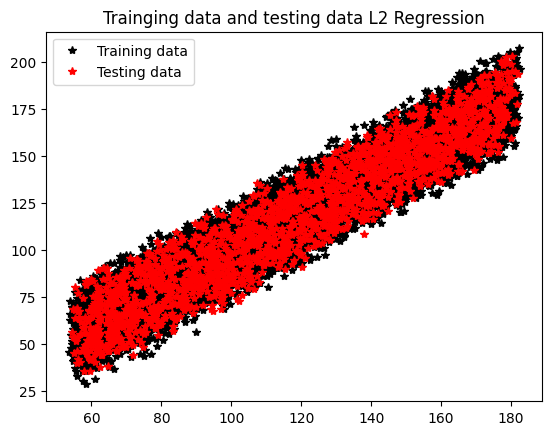

In [84]:
# import matplotlib for visualization

import matplotlib.pyplot as plt

plt.plot(ytrain_pred_ridge,  y_train, 'k*')
plt.plot(ytest_pred_ridge,  y_test, 'r*')

plt.title("Trainging data and testing data L2 Regression")
plt.legend(["Training data", "Testing data"])
plt.show()

## 7. Evaluate the results using metrics

<p>Evaluating the performance of the trained linear regression model is crucial for assessing model fit, detecting overfitting, understanding prediction accuracy, comparing models, iteratively improving the model, and establishing baseline performance. </p>
<p>The model's performance should be evaluated on both the trained data and test data sets for ensuring model effectiveness and generalization ability.</p>

In [85]:
# import the required modules
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# evauate on the training set
mae = mean_absolute_error(y_train, ytrain_pred_ridge)
print('Mean absolute error: ', mae)
mse = mean_squared_error(y_train, ytrain_pred_ridge)
print('Mean squared error: ', mse)
r2 = r2_score(y_train, ytrain_pred_ridge)
print('R2 score is: ', r2)

# evauate on the testing set
mae = mean_absolute_error(y_test, ytest_pred_ridge)
print('Mean absolute error: ', mae)
mse = mean_squared_error(y_test, ytest_pred_ridge)
print('Mean squared error: ', mse)
r2 = r2_score(y_test, ytest_pred_ridge)
print('R2 score is: ', r2)

Mean absolute error:  10.347262718150956
Mean squared error:  150.05746153726312
R2 score is:  0.895850170573243
Mean absolute error:  10.353617958850595
Mean squared error:  150.74202916954363
R2 score is:  0.8956074372091811
